# Notebook 01 — Exploration des données Orange Money

**Projet :** Modèle 4 — Détection d'anomalies sur commissions et frais  
**Auteur :** Koceila SALEM — RA&FM  
**Objectif :** Comprendre la structure du fichier `OM_Koceila.csv` (13.2 Go) sans le charger entièrement en RAM, valider les hypothèses de modélisation, identifier les pièges qualité.

---

## Plan du notebook

1. **Diagnostic taille** — combien de lignes, encoding, séparateur
2. **Échantillonnage** — lecture des 100k premières lignes pour comprendre la structure
3. **Qualité des données** — valeurs manquantes, types, taux de zéros
4. **Distributions** — répartition par `SERVICE_TYPE`, `TRANSFER_STATUS`, `IS_FINANCIAL`
5. **Statistiques financières** — moyennes/médianes des commissions par service
6. **Validation des hypothèses** — vérifie ce qu'on a supposé avant de modéliser
7. **Conclusions** — go/no-go pour le notebook 02

**Important :** ce notebook ne fait QUE de l'exploration. Aucune écriture, aucune modélisation.

## 0. Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
plt.style.use('default')
sns.set_palette('Set2')

# === PARAMÈTRES À AJUSTER ===
CSV_PATH = r'C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv'
SAMPLE_SIZE = 100_000  # nombre de lignes pour l'échantillon
ENCODING_CANDIDATS = ['utf-8', 'latin-1', 'cp1252']
SEPARATEUR_CANDIDATS = ['|', ';', ',', '\t']

print(f"Fichier cible : {CSV_PATH}")
print(f"Existe : {os.path.exists(CSV_PATH)}")
if os.path.exists(CSV_PATH):
    taille_go = os.path.getsize(CSV_PATH) / (1024**3)
    print(f"Taille : {taille_go:.2f} Go")

Fichier cible : C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv
Existe : True
Taille : 13.21 Go


## 1. Diagnostic : encoding et séparateur

Avant tout, on identifie le bon encoding et séparateur en lisant uniquement les **premières lignes** du fichier. Ça prend quelques millisecondes.

In [3]:
def detecter_encoding_separateur(path, n_bytes=10_000):
    """
    Lit les n_bytes premiers octets et teste différentes combinaisons
    encoding/séparateur. Retourne la meilleure combinaison trouvée.
    """
    resultats = []
    for enc in ENCODING_CANDIDATS:
        try:
            with open(path, 'r', encoding=enc) as f:
                premiere_ligne = f.readline()
            for sep in SEPARATEUR_CANDIDATS:
                nb_cols = len(premiere_ligne.split(sep))
                resultats.append({
                    'encoding': enc,
                    'separateur': repr(sep),
                    'nb_colonnes': nb_cols,
                    'premiere_ligne': premiere_ligne[:200]
                })
        except UnicodeDecodeError:
            continue
    return pd.DataFrame(resultats).sort_values('nb_colonnes', ascending=False)

diag = detecter_encoding_separateur(CSV_PATH)
diag.head(10)

,encoding,separateur,nb_colonnes,premiere_ligne
0,utf-8,'|',80,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
4,latin-1,'|',80,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
8,cp1252,'|',80,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
1,utf-8,';',1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
2,utf-8,"','",1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
3,utf-8,'\t',1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
5,latin-1,';',1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
6,latin-1,"','",1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
7,latin-1,'\t',1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
9,cp1252,';',1,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...


**Lecture du résultat :** la combinaison qui retourne ~76 colonnes est la bonne. Selon le descriptif Orange, on attend **76 champs**. Ajuste les variables ci-dessous selon le résultat :

In [4]:
# === À AJUSTER selon le résultat précédent ===
ENCODING = 'latin-1'  # ou 'utf-8' selon ce que tu vois ci-dessus
SEPARATEUR = '|'      # ou ';' selon ce que tu vois ci-dessus

print(f"Encoding choisi : {ENCODING}")
print(f"Séparateur choisi : {repr(SEPARATEUR)}")

Encoding choisi : latin-1
Séparateur choisi : '|'


## 2. Comptage rapide des lignes

Sur 13 Go, `wc -l` prend 30-60s mais c'est utile pour estimer le temps de traitement.

In [9]:
def compter_lignes(path, encoding=ENCODING, chunk_size=1_000_000):
    """Compte les lignes du fichier en streaming (pas de chargement RAM)."""
    print("Comptage des lignes (peut prendre 30-90s)...")
    debut = time.time()
    nb_lignes = 0
    with open(path, 'r', encoding=encoding) as f:
        for _ in f:
            nb_lignes += 1
    duree = time.time() - debut
    print(f"Total : {nb_lignes:,} lignes (temps : {duree:.1f}s)")
    return nb_lignes

# Décommente pour exécuter (long sur 13 Go)
nb_lignes_total = compter_lignes(CSV_PATH)
print(f"Estimation : ~{nb_lignes_total/12/30:.0f} transactions/jour en moyenne")

Comptage des lignes (peut prendre 30-90s)...
Total : 25,456,468 lignes (temps : 139.9s)
Estimation : ~70712 transactions/jour en moyenne


## 3. Échantillonnage : lecture des 100k premières lignes

On lit un échantillon pour comprendre la structure réelle. **C'est rapide (~5-10s)** et ça nous donne tout ce dont on a besoin pour valider nos hypothèses.

In [10]:
debut = time.time()
df_sample = pd.read_csv(
    CSV_PATH,
    sep=SEPARATEUR,
    encoding=ENCODING,
    nrows=SAMPLE_SIZE,
    low_memory=False,
    on_bad_lines='warn'
)
duree = time.time() - debut
print(f"Échantillon chargé : {len(df_sample):,} lignes × {len(df_sample.columns)} colonnes en {duree:.1f}s")
print(f"Empreinte mémoire : {df_sample.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")

Échantillon chargé : 100,000 lignes × 80 colonnes en 2.4s
Empreinte mémoire : 265.1 Mo


In [11]:
# Aperçu des 5 premières lignes
df_sample.head()

,RECEIVER_USER_ID,SENDER_USER_ID,TRANSACTION_AMOUNT,COMMISSIONS_PAID,COMMISSIONS_RECEIVED,COMMISSIONS_OTHERS,SERVICE_CHARGE_RECEIVED,SERVICE_CHARGE_PAID,TAXES,SERVICE_TYPE,TRANSFER_STATUS,SENDER_PRE_BAL,SENDER_POST_BAL,RECEIVER_PRE_BAL,RECEIVER_POST_BAL,SENDER_ACC_STATUS,RECEIVER_ACC_STATUS,ERROR_CODE,ERROR_DESC,REFERENCE_NUMBER,CREATED_ON,CREATED_BY,MODIFIED_ON,MODIFIED_BY,APP_1_DATE,APP_2_DATE,TRANSFER_ID,TRANSFER_DATETIME,SENDER_CATEGORY_CODE,SENDER_DOMAIN_CODE,SENDER_GRADE_NAME,SENDER_GROUP_ROLE,SENDER_DESIGNATION,SENDER_STATE,RECEIVER_CATEGORY_CODE,RECEIVER_DOMAIN_CODE,RECEIVER_GRADE_NAME,RECEIVER_GROUP_ROLE,RECEIVER_DESIGNATION,RECEIVER_STATE,SENDER_CITY,RECEIVER_CITY,APP_1_BY,APP_2_BY,REQUEST_SOURCE,GATEWAY_TYPE,TRANSFER_SUBTYPE,PAYMENT_TYPE,PAYMENT_NUMBER,PAYMENT_DATE,REMARKS,ACTION_TYPE,TRANSACTION_TAG,RECONCILIATION_BY,RECONCILIATION_FOR,EXT_TXN_NUMBER,ORIGINAL_REF_NUMBER,ZEBRA_AMBIGUOUS,ATTEMPT_STATUS,OTHER_MSISDN,SENDER_WALLET_NUMBER,RECEIVER_WALLET_NUMBER,TNO_MSISDN,TNO_ID,UNREG_FIRST_NAME,UNREG_LAST_NAME,UNREG_DOB,UNREG_ID_NUMBER,BULK_PAYOUT_BATCHID,IS_FINANCIAL,TRANSFER_DONE,INITIATOR_MSISDN,VALIDATOR_MSISDN,INITIATOR_COMMENTS,VALIDATOR_COMMENTS,SENDER_WALLET_NAME,RECIEVER_WALLET_NAME,SENDER_USER_TYPE,RECEIVER_USER_TYPE,TXNMODE
0,MR1006030850001,PT221022.1054.476808,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,RC,TS,11199.0,10199.0,2.779212e+08,2.779222e+08,Y,Y,NaN,NaN,R250920.0001.21000b,20/09/2025 00:01:58,PT221022.1054.476808,20/09/2025 00:01:58,PT221022.1054.476808,NaN,NaN,RC250920.0001.A10490,20/09/2025 00:01:58,SUBS,SUBS,Normal Subscriber,NaN,NaN,NaN,MERCHANT,MERCHANT,Zebra Merchant Grade,NaN,NaN,NaN,NOSY BE,NaN,NaN,NaN,BROWSER,USSD,RC,NaN,NaN,NaN,NaN,CREATION,TOP UP,NaN,NaN,R250920.0001.21000b,NaN,NaN,NaN,327813988.0,1.011221e+12,1.006031e+15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,Normal,Normal,SUBSCRIBER,MERCHANT,NaN
1,PT210614.1513.617299,PT190806.0918.289822,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,CASHIN,TS,145191804.0,145189804.0,2.409800e+04,2.609800e+04,Y,Y,NaN,NaN,NaN,20/09/2025 00:01:58,PT190806.0918.289822,20/09/2025 00:01:58,PT190806.0918.289822,NaN,NaN,CI250920.0001.B81564,20/09/2025 00:01:58,POSMER,MER,Merchant SA KENO encaissement,CU_hmmsa,TECHNIQUE,STAT73101112011010416,SUBS,SUBS,Normal Subscriber,NaN,NaN,NaN,NIF7000389892_RCS2011B00403,MAHAJANGA I,NaN,NaN,BROWSER,USSD,CASHIN,NaN,NaN,NaN,NaN,CREATION,CASHIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.011200e+14,1.011217e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,Normal,Normal,CHANNEL,SUBSCRIBER,NaN
2,PT240216.0823.781411,PT190806.0918.289822,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,CASHIN,TS,145189804.0,145188804.0,4.748000e+03,5.748000e+03,Y,Y,NaN,NaN,NaN,20/09/2025 00:01:58,PT190806.0918.289822,20/09/2025 00:01:58,PT190806.0918.289822,NaN,NaN,CI250920.0001.B81565,20/09/2025 00:01:58,POSMER,MER,Merchant SA KENO encaissement,CU_hmmsa,TECHNIQUE,STAT73101112011010416,SUBS,SUBS,subscriber PROMOGP,NaN,NaN,NaN,NIF7000389892_RCS2011B00403,MAHAJANGAI,NaN,NaN,BROWSER,USSD,CASHIN,NaN,NaN,NaN,NaN,CREATION,CASHIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.011200e+14,1.011225e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,Normal,Normal,CHANNEL,SUBSCRIBER,NaN
3,PT180821.1452.517463,PT250512.1430.007175,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,MERCHPAY,TS,10000.0,9000.0,2.638660e+09,2.638661e+09,Y,Y,NaN,NaN,NaN,20/09/2025 00:02:01,PT250512.1430.007175,20/09/2025 00:02:01,PT250512.1430.007175,NaN,NaN,MP250920.0002.A27711,20/09/2025 00:02:01,SUBS,SUBS,Normal Subscriber,NaN,NaN,MADA,POSMER,MER,Merchant SA grade Forfait,CU_hmmsa,TECHNIQUE,STAT61202111997010016,Antananarivo Atsimondrano,NIF2000002340_RCS1997B00447,NaN,NaN,BROWSER,USSD,MERCHPAY,NaN,NaN,NaN,NaN,CREATION,PAIEMENT MARCHAND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.011229e+12,1.011200e+14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,Normal,Normal,SUBSCRIBER,CHANNEL,NaN
4,MR1006030850001,PT230530.1235.063671,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,RC,TS,5577.0,4577.0,2.779222e+08,2.779232e+08,Y,Y,NaN,NaN,R250920.0002.210001,20/09/2025 00:02:01,PT230530.1235.06367

In [12]:
# Liste complète des colonnes (vérifier qu'on a bien les 76 attendues)
print(f"Nombre de colonnes : {len(df_sample.columns)}")
print("\nColonnes :")
for i, col in enumerate(df_sample.columns, 1):
    print(f"  {i:2d}. {col} ({df_sample[col].dtype})")

Nombre de colonnes : 80

Colonnes :
   1. RECEIVER_USER_ID (object)
   2. SENDER_USER_ID (object)
   3. TRANSACTION_AMOUNT (float64)
   4. COMMISSIONS_PAID (float64)
   5. COMMISSIONS_RECEIVED (float64)
   6. COMMISSIONS_OTHERS (float64)
   7. SERVICE_CHARGE_RECEIVED (float64)
   8. SERVICE_CHARGE_PAID (float64)
   9. TAXES (float64)
  10. SERVICE_TYPE (object)
  11. TRANSFER_STATUS (object)
  12. SENDER_PRE_BAL (float64)
  13. SENDER_POST_BAL (float64)
  14. RECEIVER_PRE_BAL (float64)
  15. RECEIVER_POST_BAL (float64)
  16. SENDER_ACC_STATUS (object)
  17. RECEIVER_ACC_STATUS (object)
  18. ERROR_CODE (float64)
  19. ERROR_DESC (object)
  20. REFERENCE_NUMBER (object)
  21. CREATED_ON (object)
  22. CREATED_BY (object)
  23. MODIFIED_ON (object)
  24. MODIFIED_BY (object)
  25. APP_1_DATE (float64)
  26. APP_2_DATE (object)
  27. TRANSFER_ID (object)
  28. TRANSFER_DATETIME (object)
  29. SENDER_CATEGORY_CODE (object)
  30. SENDER_DOMAIN_CODE (object)
  31. SENDER_GRADE_NAME (object)


## 4. Qualité des données : valeurs manquantes et taux de zéros

Point critique pour le modèle 4 : si les commissions sont à 99% à zéro, l'Isolation Forest ne pourra pas distinguer le signal du bruit. **À vérifier impérativement.**

In [13]:
COLS_FINANCIERES = [
    'TRANSACTION_AMOUNT',
    'COMMISSIONS_PAID',
    'COMMISSIONS_RECEIVED',
    'COMMISSIONS_OTHERS',
    'SERVICE_CHARGE_RECEIVED',
    'SERVICE_CHARGE_PAID',
    'TAXES'
]

def diagnostic_qualite(df, cols):
    """Pour chaque colonne financière : NaN, zéros, statistiques."""
    rows = []
    for col in cols:
        if col not in df.columns:
            print(f"⚠️  Colonne manquante : {col}")
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        rows.append({
            'colonne': col,
            'nb_total': len(s),
            'nb_nan': s.isna().sum(),
            'pct_nan': f"{s.isna().mean()*100:.1f}%",
            'nb_zeros': (s == 0).sum(),
            'pct_zeros': f"{(s == 0).mean()*100:.1f}%",
            'min': s.min(),
            'mediane': s.median(),
            'moyenne': s.mean(),
            'max': s.max()
        })
    return pd.DataFrame(rows)

diag_qualite = diagnostic_qualite(df_sample, COLS_FINANCIERES)
diag_qualite

,colonne,nb_total,nb_nan,pct_nan,nb_zeros,pct_zeros,min,mediane,moyenne,max
0,TRANSACTION_AMOUNT,100000,0,0.0%,0,0.0%,1.0,2000.0,38407.399016,23737500.0
1,COMMISSIONS_PAID,100000,0,0.0%,68540,68.5%,0.0,0.0,90.073320,17110.0
2,COMMISSIONS_RECEIVED,100000,0,0.0%,99841,99.8%,0.0,0.0,0.080227,1200.0
3,COMMISSIONS_OTHERS,100000,0,0.0%,99924,99.9%,0.0,0.0,38.118493,453000.0
4,SERVICE_CHARGE_RECEIVED,100000,0,0.0%,80149,80.1%,0.0,0.0,217.151655,53900.0
5,SERVICE_CHARGE_PAID,100000,0,0.0%,99909,99.9%,0.0,0.0,0.644200,7200.0
6,TAXES,100000,0,0.0%,100000,100.0%,0.0,0.0,0.000000,0.0


**Interprétation à faire :**

- Si `pct_zeros > 95%` sur `COMMISSIONS_RECEIVED` → soit l'échantillon contient surtout des services non commissionnés (RC = recharge, vu dans tes exemples), soit on doit creuser par `SERVICE_TYPE`.
- Si `pct_nan > 50%` → problème de parsing à régler avant de continuer.
- Les valeurs négatives sur `TRANSACTION_AMOUNT` indiquent des rollbacks ou des erreurs de saisie.

## 5. Répartition par SERVICE_TYPE et TRANSFER_STATUS

Compréhension du périmètre métier.

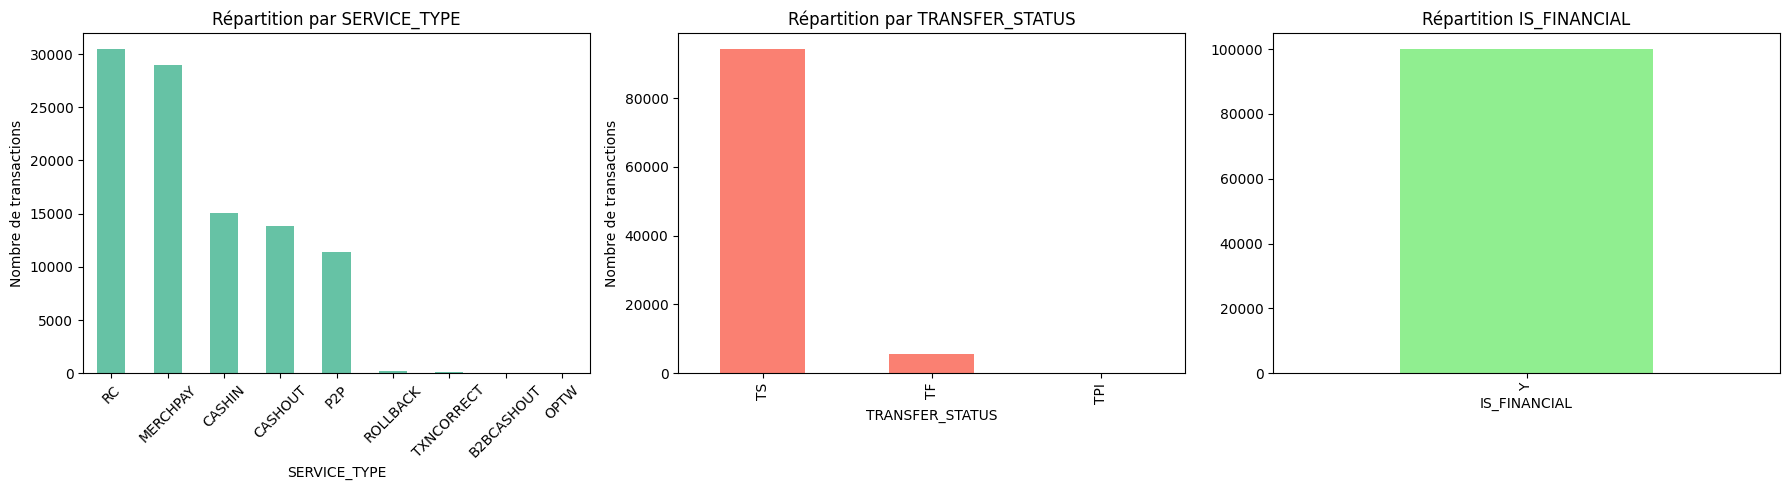


=== SERVICE_TYPE ===
SERVICE_TYPE
RC            30.47%
MERCHPAY      28.99%
CASHIN        15.04%
CASHOUT       13.82%
P2P           11.35%
ROLLBACK       0.23%
TXNCORRECT     0.09%
B2BCASHOUT     0.01%
OPTW            0.0%
Name: proportion, dtype: object

=== TRANSFER_STATUS ===
TRANSFER_STATUS
TS     94.27%
TF      5.69%
TPI     0.04%
Name: proportion, dtype: object


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_sample['SERVICE_TYPE'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Répartition par SERVICE_TYPE')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)

df_sample['TRANSFER_STATUS'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Répartition par TRANSFER_STATUS')
axes[1].set_ylabel('Nombre de transactions')

if 'IS_FINANCIAL' in df_sample.columns:
    df_sample['IS_FINANCIAL'].value_counts().plot(kind='bar', ax=axes[2], color='lightgreen')
    axes[2].set_title('Répartition IS_FINANCIAL')

plt.tight_layout()
plt.show()

# Tableaux
print("\n=== SERVICE_TYPE ===")
print(df_sample['SERVICE_TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\n=== TRANSFER_STATUS ===")
print(df_sample['TRANSFER_STATUS'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

## 6. Statistiques financières par SERVICE_TYPE

C'est le tableau le plus important pour le Modèle 4 : il révèle la signature financière normale de chaque service.

In [15]:
# Filtre périmètre Modèle 4 : seulement les transactions financières réussies
df_filtre = df_sample.copy()
if 'IS_FINANCIAL' in df_filtre.columns:
    df_filtre = df_filtre[df_filtre['IS_FINANCIAL'] == 'Y']
df_filtre = df_filtre[df_filtre['TRANSFER_STATUS'] == 'TS']

print(f"Après filtrage IS_FINANCIAL=Y et TRANSFER_STATUS=TS : {len(df_filtre):,} lignes")
print(f"Soit {len(df_filtre)/len(df_sample)*100:.1f}% de l'échantillon")

Après filtrage IS_FINANCIAL=Y et TRANSFER_STATUS=TS : 94,269 lignes
Soit 94.3% de l'échantillon


In [16]:
# Cast numérique des colonnes financières
for col in COLS_FINANCIERES:
    if col in df_filtre.columns:
        df_filtre[col] = pd.to_numeric(df_filtre[col], errors='coerce')

# Stats par service
stats_par_service = df_filtre.groupby('SERVICE_TYPE').agg(
    nb_transactions=('TRANSFER_ID', 'count') if 'TRANSFER_ID' in df_filtre.columns else ('SERVICE_TYPE', 'count'),
    montant_moyen=('TRANSACTION_AMOUNT', 'mean'),
    montant_total=('TRANSACTION_AMOUNT', 'sum'),
    com_payee_moy=('COMMISSIONS_PAID', 'mean'),
    com_recue_moy=('COMMISSIONS_RECEIVED', 'mean'),
    frais_recus_moy=('SERVICE_CHARGE_RECEIVED', 'mean'),
    taxes_moy=('TAXES', 'mean')
).round(2)

stats_par_service['marge_nette'] = (
    stats_par_service['com_recue_moy']
    + stats_par_service['frais_recus_moy']
    - stats_par_service['com_payee_moy']
).round(2)

stats_par_service.sort_values('nb_transactions', ascending=False)

,nb_transactions,montant_moyen,montant_total,com_payee_moy,com_recue_moy,frais_recus_moy,taxes_moy,marge_nette
SERVICE_TYPE,,,,,,,,
RC,28564,1165.42,3.328900e+07,23.88,0.00,0.00,0.0,-23.88
MERCHPAY,27597,6044.60,1.668127e+08,0.00,0.01,18.02,0.0,18.03
CASHIN,14977,89602.31,1.341974e+09,158.30,0.10,101.29,0.0,-56.91
CASHOUT,12317,78882.88,9.716004e+08,470.56,0.00,1188.96,0.0,718.40
P2P,10483,103117.48,1.080981e+09,13.92,0.00,479.08,0.0,465.16
ROLLBACK,229,979.04,2.242000e+05,0.00,27.27,0.00,0.0,27.27
TXNCORRECT,91,36727.56,3.342208e+06,0.00,0.00,0.00,0.0,0.00
B2BCASHOUT,10,169327.50,1.693275e+06,1254.10,0.00,2582.50,0.0,1328.40
OPTW,1,5600.00,5.600000e+03,0.00,0.00,0.00,0.0,0.00


**Lecture critique :**

- Les services à `com_payee_moy = 0` ET `com_recue_moy = 0` sont des services non commissionnés → **à exclure du modèle 4**
- Les services restants sont le périmètre utile pour la détection d'anomalies
- La `marge_nette` doit être ≥ 0 sur l'agrégé. Une marge négative chronique sur un service = problème de tarification (fuite de revenu)

## 7. Plage temporelle de l'échantillon

In [17]:
# Parser la colonne CREATED_ON ou TRANSFER_DATETIME
for col_date in ['CREATED_ON', 'TRANSFER_DATETIME']:
    if col_date in df_sample.columns:
        try:
            df_sample[col_date] = pd.to_datetime(df_sample[col_date], errors='coerce', dayfirst=True)
            print(f"\n=== {col_date} ===")
            print(f"  Min  : {df_sample[col_date].min()}")
            print(f"  Max  : {df_sample[col_date].max()}")
            print(f"  NaN  : {df_sample[col_date].isna().sum()}")
        except Exception as e:
            print(f"Erreur parsing {col_date}: {e}")


=== CREATED_ON ===
  Min  : 2025-09-20 00:00:00
  Max  : 2025-09-20 08:14:00
  NaN  : 0

=== TRANSFER_DATETIME ===
  Min  : 2025-09-20 00:00:00
  Max  : 2025-09-20 08:17:21
  NaN  : 0


## 8. Distribution des montants (utile pour calibrer les features)

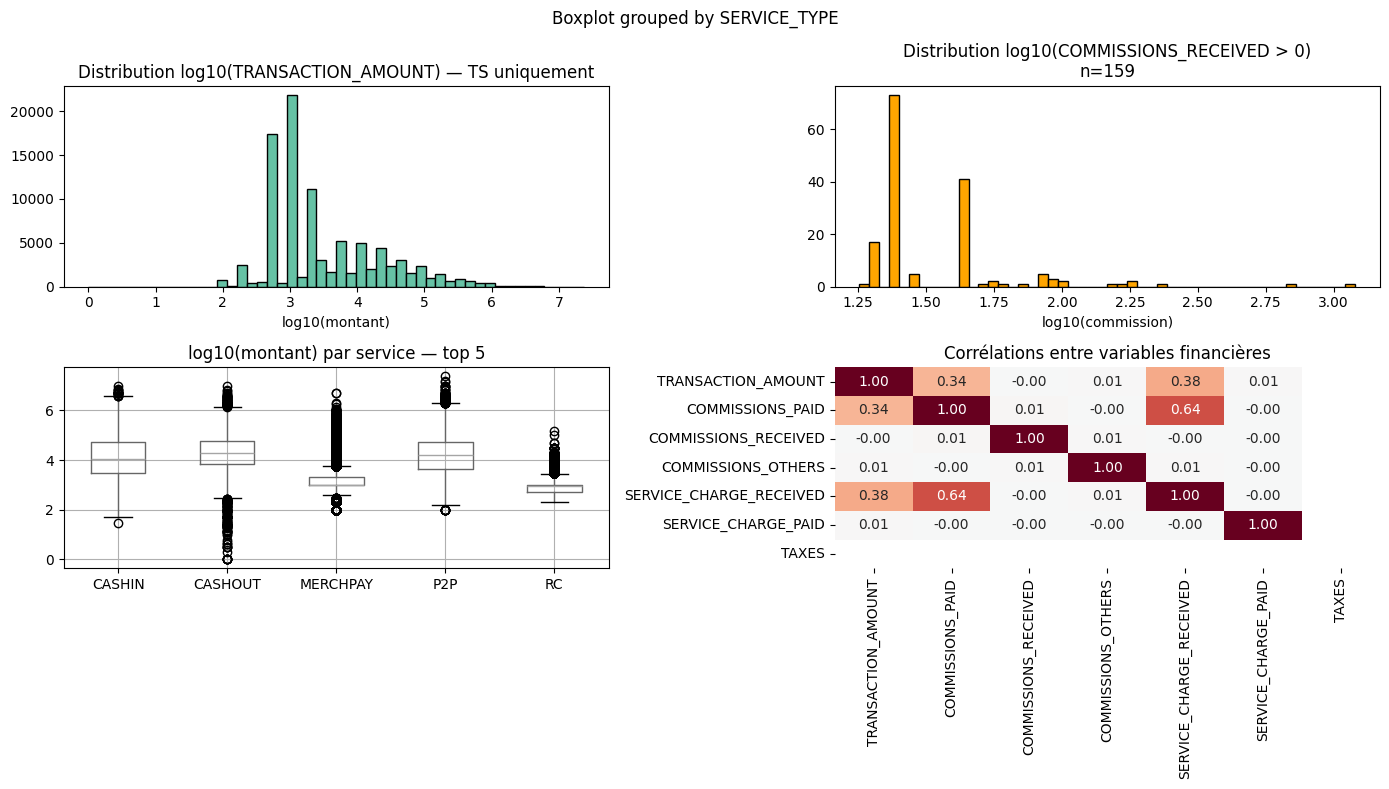

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Distribution log des montants (les montants OM ont une distribution très skewed)
amount_pos = df_filtre['TRANSACTION_AMOUNT'][df_filtre['TRANSACTION_AMOUNT'] > 0]
axes[0,0].hist(np.log10(amount_pos), bins=50, edgecolor='black')
axes[0,0].set_title('Distribution log10(TRANSACTION_AMOUNT) — TS uniquement')
axes[0,0].set_xlabel('log10(montant)')

# Distribution des commissions reçues (non nulles)
com_pos = df_filtre['COMMISSIONS_RECEIVED'][df_filtre['COMMISSIONS_RECEIVED'] > 0]
if len(com_pos) > 0:
    axes[0,1].hist(np.log10(com_pos), bins=50, edgecolor='black', color='orange')
    axes[0,1].set_title(f'Distribution log10(COMMISSIONS_RECEIVED > 0)\nn={len(com_pos):,}')
    axes[0,1].set_xlabel('log10(commission)')

# Boxplot par service (échantillon des top services)
top_services = df_filtre['SERVICE_TYPE'].value_counts().head(5).index
df_top = df_filtre[df_filtre['SERVICE_TYPE'].isin(top_services)]
df_top_pos = df_top[df_top['TRANSACTION_AMOUNT'] > 0].copy()
df_top_pos['log_amount'] = np.log10(df_top_pos['TRANSACTION_AMOUNT'])
df_top_pos.boxplot(column='log_amount', by='SERVICE_TYPE', ax=axes[1,0])
axes[1,0].set_title('log10(montant) par service — top 5')
axes[1,0].set_xlabel('')

# Heatmap corrélations financières
corr = df_filtre[COLS_FINANCIERES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1,1], cbar=False)
axes[1,1].set_title('Corrélations entre variables financières')

plt.tight_layout()
plt.show()

## 9. Validation des hypothèses du Modèle 4

Check-list à valider AVANT de passer au notebook 02.

In [19]:
checks = []

# H1 : Les 76 colonnes attendues sont présentes
checks.append({
    'hypothèse': 'Nombre de colonnes ≈ 76',
    'résultat': len(df_sample.columns),
    'statut': '✅' if 70 <= len(df_sample.columns) <= 80 else '❌'
})

# H2 : Au moins un sous-ensemble de transactions ont des commissions non nulles
com_non_nulles = (df_filtre['COMMISSIONS_RECEIVED'] > 0).sum()
checks.append({
    'hypothèse': 'Au moins 1% des transactions ont des commissions reçues > 0',
    'résultat': f"{com_non_nulles}/{len(df_filtre)} ({com_non_nulles/len(df_filtre)*100:.2f}%)",
    'statut': '✅' if com_non_nulles/len(df_filtre) > 0.01 else '⚠️'
})

# H3 : Au moins 3 services ont des commissions actives
services_actifs = (df_filtre.groupby('SERVICE_TYPE')['COMMISSIONS_RECEIVED'].sum() > 0).sum()
checks.append({
    'hypothèse': 'Au moins 3 SERVICE_TYPE avec commissions > 0',
    'résultat': f"{services_actifs} services",
    'statut': '✅' if services_actifs >= 3 else '⚠️'
})

# H4 : Présence de TRANSFER_STATUS = TS
ts_count = (df_sample['TRANSFER_STATUS'] == 'TS').sum()
checks.append({
    'hypothèse': 'Présence de transactions TS (Successful)',
    'résultat': f"{ts_count}/{len(df_sample)} ({ts_count/len(df_sample)*100:.1f}%)",
    'statut': '✅' if ts_count > 0 else '❌'
})

# H5 : Dates parsables
if 'CREATED_ON' in df_sample.columns:
    dates_ok = df_sample['CREATED_ON'].notna().sum()
    checks.append({
        'hypothèse': 'CREATED_ON parsable en datetime',
        'résultat': f"{dates_ok}/{len(df_sample)} ({dates_ok/len(df_sample)*100:.1f}%)",
        'statut': '✅' if dates_ok/len(df_sample) > 0.99 else '⚠️'
    })

pd.DataFrame(checks)

,hypothèse,résultat,statut
0,Nombre de colonnes ≈ 76,80,✅
1,Au moins 1% des transactions ont des commissio...,159/94269 (0.17%),⚠️
2,Au moins 3 SERVICE_TYPE avec commissions > 0,3 services,✅
3,Présence de transactions TS (Successful),94269/100000 (94.3%),✅
4,CREATED_ON parsable en datetime,100000/100000 (100.0%),✅


## 10. Conclusions et go/no-go

**Si tous les checks sont ✅ :** tu peux passer au notebook `02_aggregation_pipeline.ipynb`.

**Si certains checks sont ⚠️ ou ❌ :** investigue avant de continuer.

Cas typiques à régler ici :
- Encoding incorrect → texte illisible dans les colonnes
- Séparateur incorrect → toutes les colonnes dans une seule
- Tous les `COMMISSIONS_*` à 0 → soit l'échantillon est biaisé (lis les 100k suivantes), soit le périmètre du fichier exclut les services commissionnés
- Dates au format inhabituel → ajuster `pd.to_datetime` avec un `format` explicite

**Décisions à acter pour le notebook 02 :**
- Liste des SERVICE_TYPE à modéliser (ceux avec activité commissionnelle)
- Encoding et séparateur définitifs
- Format de date (avec `format='%d/%m/%Y %H:%M:%S'` ou autre)
- Choix de la colonne date principale (CREATED_ON vs TRANSFER_DATETIME)